In [30]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
#importing the netflix dataset
df = pd.read_csv('netflix_titles.csv')
df.head()
df.info()
#the data set contains 12 columns and 8807 rows.
# the columns are: show_id, type, title, director, cast, country, date_added, release_year, rating, duration, listed_in, description.
# The dataset contains information about movies and TV shows available on Netflix.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [13]:
print(df.columns.tolist())


['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [14]:
#now since director column has the most number of null values, we will drop all the rows with null values in the director column.
df = df.dropna(subset=['director'])
# the cast column is not very useful for our analysis, so we will drop the cast column.
df = df.drop(columns=['cast'])
# the country column has some null values, we will fill those null values with the mode of the country column.
df['country'] = df['country'].fillna(df['country'].mode()[0])
# the show_id column is not very useful for our analysis, so we will drop the show_id column.
df = df.drop(columns=['show_id'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6173 entries, 0 to 8806
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          6173 non-null   object
 1   title         6173 non-null   object
 2   director      6173 non-null   object
 3   country       6173 non-null   object
 4   date_added    6173 non-null   object
 5   release_year  6173 non-null   int64 
 6   rating        6172 non-null   object
 7   duration      6170 non-null   object
 8   listed_in     6173 non-null   object
 9   description   6173 non-null   object
dtypes: int64(1), object(9)
memory usage: 530.5+ KB


In [19]:
# we will fill the missing values in rating column with the mode of the rating column.
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
#we will fill the missing values in duration column with the mode of the duration column.
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6173 entries, 0 to 8806
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          6173 non-null   object
 1   title         6173 non-null   object
 2   director      6173 non-null   object
 3   country       6173 non-null   object
 4   date_added    6173 non-null   object
 5   release_year  6173 non-null   int64 
 6   rating        6173 non-null   object
 7   duration      6173 non-null   object
 8   listed_in     6173 non-null   object
 9   description   6173 non-null   object
dtypes: int64(1), object(9)
memory usage: 530.5+ KB


In [ ]:
#since the date_added column is of object type, we will convert it to datetime type.
df['date_added']=df['date_added'].str.strip()
df['date_added'] = pd.to_datetime(df['date_added'], format='%B %d, %Y', errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6173 entries, 0 to 8806
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          6173 non-null   object        
 1   title         6173 non-null   object        
 2   director      6173 non-null   object        
 3   country       6173 non-null   object        
 4   date_added    6173 non-null   datetime64[ns]
 5   release_year  6173 non-null   int64         
 6   rating        6173 non-null   object        
 7   duration      6173 non-null   object        
 8   listed_in     6173 non-null   object        
 9   description   6173 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 659.5+ KB


In [ ]:
# since date is not explicitly needed, we will extract only the month since we already have year in release_year column. We will create a new column called month_added which will contain the month in which the movie or tv show was added to netflix.
df['month_added'] = df['date_added'].dt.month

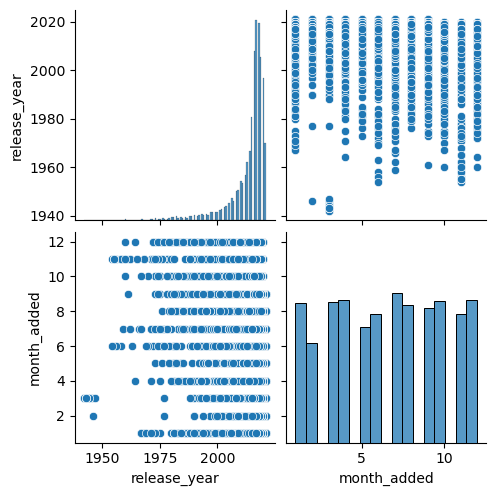

In [31]:
# now we will visualize the correlation between the columns in the dataset using a heatmap.
sns.pairplot(df)
plt.show()